In [ ]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint


from network import NetCNN1D, NetCNN2D_CSP, NetCNN2D_CSP_GAP, build_functional_cnn2D

from mne.decoding import CSP

import numpy as np
import sys, os

import dataset_NewEEG
from config_NewEEG import Config

import matplotlib.pyplot as plt


import pandas as pd
import pickle
import tqdm, logging, warnings

import train_evaluate

from quantizeml.models import QuantizationParams, quantize
import akida
from cnn2snn import convert, set_akida_version, AkidaVersion



# Filter out info and warnings from TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('tensorflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')


config = Config()

config.model_type = '2D'


# Choose from: 'CLeft', 'CRight', 'CUp' and 'CDown'
config.used_classes = [['CUp'], ['CDown']]
config.session_type = 'S2'




config.test_session = 11


config.t_start = 0 
config.t_end = 3.0

config.window_size = 2.0




config.n_csp_components = 3


# All available channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']
config.used_channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']





################# Changed in Adaptation #################

config.stride = 0.5


config.epochs = 50
config.batch_size = 64


config.learning_rate = 1e-4
config.label_smoothing = 0.05
config.weight_decay = 2e-5

In [2]:
X, y = [], []
for i in range(1, 12):
    if i == config.test_session:
        continue
    Xi, yi = dataset_NewEEG.session_dataset(config, f'I{i:02d}')
    X.append(Xi)
    y.append(yi)


X, y = np.concatenate(X), np.concatenate(y)

print(X.shape)
print(y.shape)

shuffle_indices = np.random.permutation(len(y))
X_train, Y_train = X[shuffle_indices], y[shuffle_indices]


X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')
shuffle_indices = np.random.permutation(len(y))
X_valid, Y_valid = X[shuffle_indices], y[shuffle_indices]


    

(320, 13, 750)
(320,)


Epoch 1/50
15/15 [==============================] - 5s 195ms/step - loss: 0.7581 - acc: 0.4948 - val_loss: 0.6901 - val_acc: 0.5432
Epoch 2/50
15/15 [==============================] - 0s 11ms/step - loss: 0.7213 - acc: 0.4948 - val_loss: 0.6861 - val_acc: 0.5926
Epoch 3/50
15/15 [==============================] - 2s 174ms/step - loss: 0.7029 - acc: 0.5385 - val_loss: 0.6895 - val_acc: 0.6049
Epoch 4/50
15/15 [==============================] - 2s 147ms/step - loss: 0.6971 - acc: 0.5417 - val_loss: 0.6935 - val_acc: 0.5432
Epoch 5/50
15/15 [==============================] - 2s 146ms/step - loss: 0.6896 - acc: 0.5427 - val_loss: 0.6947 - val_acc: 0.5679
Epoch 6/50
15/15 [==============================] - 2s 152ms/step - loss: 0.6766 - acc: 0.5688 - val_loss: 0.6985 - val_acc: 0.5679
Epoch 7/50
15/15 [==============================] - 2s 150ms/step - loss: 0.6675 - acc: 0.5906 - val_loss: 0.7070 - val_acc: 0.4938
Epoch 8/50
15/15 [==============================] - 0s 9ms/step - loss: 0.667

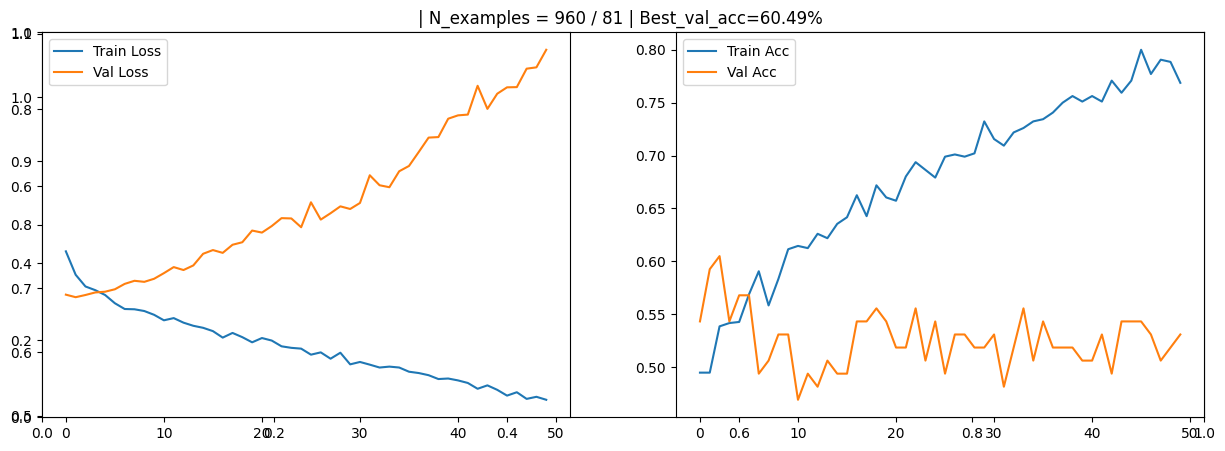

In [3]:
if config.model_type == '2D':
    model = NetCNN2D_CSP(len(config.used_classes))

    model, csp, val_acc = train_evaluate.train_evalute(config, X_train, Y_train, X_valid, Y_valid, model, choose_on='acc', plot_graphs=True)


elif config.model_type == '2D_GAP':
    model = NetCNN2D_CSP_GAP(len(config.used_classes))

    model, csp, val_acc = train_evaluate.train_evalute(config, X_train, Y_train, X_valid, Y_valid, model, choose_on='val_acc', plot_graphs=True)


    naming = config.used_classes[0][0][1] + config.used_classes[1][0][1] + '_gap'

    model.save(os.path.join('saved_models', naming+'.tf'), save_format='tf')
    print(f"Best model saved  with validation accuracy: {val_acc:.4f}")

    with open(os.path.join('saved_models','csp'+naming+'.pkl'), 'wb') as f:
        pickle.dump(csp, f)

else:
    model = NetCNN1D(len(config.used_classes))

In [4]:
if config.model_type == '2D':


    X_train, _ = dataset_NewEEG.slice_EEG_epoch(config, X_train, Y_train)
    X_valid, Y_valid = dataset_NewEEG.slice_EEG_epoch(config, X_valid, Y_valid)

    X_train = csp.transform(X_train)
    X_valid = csp.transform(X_valid)

    X_train = np.expand_dims(X_train, 3)
    X_valid = np.expand_dims(X_valid, 3)

    Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes = len(config.used_classes))


    Xq = ((X_train - X_train.min()) / (X_train.max() - X_train.min()) * 255).astype(np.uint8)
    Xqv = ((X_valid - X_valid.min()) / (X_valid.max() - X_valid.min()) * 255).astype(np.uint8)




    functional_model = build_functional_cnn2D(n_classes=2, input_shape=(3, 500, 1))
    functional_model.set_weights(model.get_weights())


    qparams = QuantizationParams(input_weight_bits=8, weight_bits=4, activation_bits=4, per_tensor_activations=True)
    quantized_model = quantize(functional_model, qparams=qparams, samples=Xq, num_samples=300, batch_size=64, epochs=10)
    quantized_model.summary()



    quantized_model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=config.label_smoothing),
            optimizer=keras.optimizers.Adam(learning_rate=config.learning_rate, weight_decay = config.weight_decay), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 

    loss, acc = quantized_model.evaluate(Xqv, Y_valid)
    print("Quantized model validation acc = ", acc)




    with set_akida_version(AkidaVersion.v1):
        model_akida = convert(quantized_model)
        print()
        model_akida.summary()




    naming = config.used_classes[0][0][1] + config.used_classes[1][0][1]

    model.save(os.path.join('saved_models',naming+'.tf'), save_format='tf')

    with open(os.path.join('saved_models','csp' +naming+ '.pkl'), 'wb') as f:
        pickle.dump(csp, f)

    model_akida.save(os.path.join('saved_models', naming+'.fbz'))

5/5 [==============================] - 0s 6ms/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 3, 500, 1)]       0         
                                                                 
 conv2d_2 (QuantizedConv2D)  (None, 1, 72, 8)          976       
                                                                 
 re_lu_3 (QuantizedReLU)     (None, 1, 72, 8)          2         
                                                                 
 conv2d_3 (QuantizedConv2D)  (None, 1, 15, 16)         6288      
                                                                 
 re_lu_4 (QuantizedReLU)     (None, 1, 15, 16)         2         
                                                                 
 flatten_1 (QuantizedFlatte  (None, 240)               0         
 n)                                                              
          